# M16 — Notebook de Comparação Controlada e Análise de Erros
**LGN 2026.3 — Aula 6**  
**versão final — M4 (Trilha A) com extensão e uso final da partição de teste**

## Objetivo
Comparar duas representações TF-IDF sob condições controladas, investigar diferenças de comportamento e analisar erros para formular uma hipótese e uma questão experimental preliminar.

> **Regra da aula:** mudar uma variável por vez.  
> **Teste:** permanece preservado — sem `transform`, `predict`, métrica ou inspeção de rótulos.

> **Corpora v2:** 5.000 registros por corpus, com 3.500 registros originalmente destinados ao treino, 750 à validação e 750 ao teste. Os 30 textos ausentes de cada corpus estão no treino e são removidos apenas para a modelagem, resultando em 3.470 textos utilizáveis no treino.


> **Extensão da Aula 8:** as Partes A–E permanecem como registro da comparação em treino/validação. A nova Parte F deve ser executada somente depois que a configuração final estiver definida e registrada no M4.


## 1. Carregar o corpus e definir o alvo

Escolha o mesmo corpus usado no M15.  
O M16 **não reconstrói o M15**: ele parte das mesmas convenções de arquivo, texto, alvo e `particao_recomendada`.

**Pergunta:** qual corpus e qual alvo estamos investigando?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

ARQUIVO = "P03_solicitacoes_atendimento_v2.csv"  # troque por P01 ou P02, se necessário

MAPA_ALVO = {
    "P01_reclamacoes_assunto_v2.csv": "categoria_assunto",
    "P02_sentimento_avaliacoes_v2.csv": "sentimento",
    "P03_solicitacoes_atendimento_v2.csv": "setor_destino",
}

COL_TEXTO = "texto"
COL_ALVO = MAPA_ALVO[ARQUIVO]

df = pd.read_csv(ARQUIVO, sep=";", encoding="utf-8-sig")

colunas_necessarias = {
    COL_TEXTO,
    COL_ALVO,
    "particao_recomendada",
}

faltantes = colunas_necessarias - set(df.columns)
assert not faltantes, f"Colunas ausentes no arquivo: {sorted(faltantes)}"

print("Corpus:", ARQUIVO)
print("Coluna de texto:", COL_TEXTO)
print("Alvo:", COL_ALVO)
print("Dimensões originais:", df.shape)
print("Estrutura mínima conferida.")


Corpus: P03_solicitacoes_atendimento_v2.csv
Coluna de texto: texto
Alvo: setor_destino
Dimensões originais: (5000, 6)
Estrutura mínima conferida.


## 2. Reproduzir o estado de entrada do M15

Preserve a divisão fornecida no corpus e remova somente registros sem texto para a modelagem.

**Não refaça a divisão.**

Cada corpus v2 contém originalmente **3.500 registros em treino, 750 em validação e 750 em teste**.  
Os **30 textos ausentes** estão no treino; por isso, após a remoção desses registros, a modelagem usa **3.470 textos de treino**, mantendo validação e teste com 750 registros cada.

O teste continua apenas separado e contabilizado; não será transformado, previsto, avaliado ou inspecionado.


In [2]:
CONTAGENS_ORIGINAIS = {
    "treino": 3500,
    "validacao": 750,
    "teste": 750,
}

contagens_originais = df["particao_recomendada"].value_counts().to_dict()

for particao, esperado in CONTAGENS_ORIGINAIS.items():
    observado = contagens_originais.get(particao, 0)
    print(f"{particao}: {observado} | esperado: {esperado}")
    assert observado == esperado, f"Contagem original de {particao} diferente da esperada."

ausentes_treino = df.loc[
    df["particao_recomendada"] == "treino", COL_TEXTO
].isna().sum()

ausentes_validacao = df.loc[
    df["particao_recomendada"] == "validacao", COL_TEXTO
].isna().sum()

ausentes_teste = df.loc[
    df["particao_recomendada"] == "teste", COL_TEXTO
].isna().sum()

print("\nTextos ausentes:")
print("Treino:", ausentes_treino)
print("Validação:", ausentes_validacao)
print("Teste:", ausentes_teste)

assert ausentes_treino == 30, "Esperavam-se 30 textos ausentes no treino."
assert ausentes_validacao == 0, "Não eram esperados textos ausentes na validação."
assert ausentes_teste == 0, "Não eram esperados textos ausentes no teste."

df_modelo = df.dropna(subset=[COL_TEXTO]).copy()

treino = df_modelo[df_modelo["particao_recomendada"] == "treino"].copy()
validacao = df_modelo[df_modelo["particao_recomendada"] == "validacao"].copy()
teste = df_modelo[df_modelo["particao_recomendada"] == "teste"].copy()

CONTAGENS_MODELAGEM = {
    "treino": 3470,
    "validacao": 750,
    "teste": 750,
}

print("\nApós remover somente textos ausentes:")
print("Treino utilizável:", len(treino), "| esperado:", CONTAGENS_MODELAGEM["treino"])
print("Validação:", len(validacao), "| esperado:", CONTAGENS_MODELAGEM["validacao"])
print("Teste preservado:", len(teste), "| esperado:", CONTAGENS_MODELAGEM["teste"])

assert len(treino) == CONTAGENS_MODELAGEM["treino"], "Contagem de treino utilizável diferente da esperada."
assert len(validacao) == CONTAGENS_MODELAGEM["validacao"], "Contagem de validação diferente da esperada."
assert len(teste) == CONTAGENS_MODELAGEM["teste"], "Contagem de teste diferente da esperada."

print("\nPartições v2 conferidas. Não refaça o split.")


treino: 3500 | esperado: 3500
validacao: 750 | esperado: 750
teste: 750 | esperado: 750

Textos ausentes:
Treino: 30
Validação: 0
Teste: 0

Após remover somente textos ausentes:
Treino utilizável: 3470 | esperado: 3470
Validação: 750 | esperado: 750
Teste preservado: 750 | esperado: 750

Partições v2 conferidas. Não refaça o split.


## 3. Confirmar a comparação controlada

Nesta aula, vamos alterar **uma única variável experimental**:

- **Representação A:** TF-IDF com unigramas
- **Representação B:** TF-IDF com unigramas + bigramas

Permanecem fixos:

- mesmo corpus
- mesmo treino
- mesma validação
- mesmo alvo
- mesma `LogisticRegression`
- mesmas métricas

**Variável experimental:** `ngram_range`


In [3]:
controle_experimental = {
    "corpus": ARQUIVO,
    "alvo": COL_ALVO,
    "classificador": "LogisticRegression(max_iter=1000, random_state=42)",
    "metricas": ["acuracia", "f1_macro", "matriz_de_confusao"],
    "variavel_experimental": "ngram_range",
    "representacao_A": "(1, 1)",
    "representacao_B": "(1, 2)",
}

display(controle_experimental)


{'corpus': 'P03_solicitacoes_atendimento_v2.csv',
 'alvo': 'setor_destino',
 'classificador': 'LogisticRegression(max_iter=1000, random_state=42)',
 'metricas': ['acuracia', 'f1_macro', 'matriz_de_confusao'],
 'variavel_experimental': 'ngram_range',
 'representacao_A': '(1, 1)',
 'representacao_B': '(1, 2)'}

## 4. Preparar treino e validação

O aprendizado continua restrito ao treino.

- `fit_transform` será usado no treino
- `transform` será usado na validação
- nenhuma matriz de teste será criada


In [4]:
y_treino = treino[COL_ALVO]
y_validacao = validacao[COL_ALVO]

assert treino[COL_ALVO].isna().sum() == 0
assert validacao[COL_ALVO].isna().sum() == 0
assert set(validacao[COL_ALVO]).issubset(set(treino[COL_ALVO]))

assert set(treino.index).isdisjoint(set(validacao.index))
assert set(treino.index).isdisjoint(set(teste.index))
assert set(validacao.index).isdisjoint(set(teste.index))

print("Treino e validação conferidos.")
print("Teste segue fora da representação e da previsão.")


Treino e validação conferidos.
Teste segue fora da representação e da previsão.


# Parte A — Representação A

## 5. TF-IDF com unigramas

**Pergunta:** qual comportamento obtemos quando cada atributo textual deriva de termos individuais?


In [5]:
vetorizador_A = TfidfVectorizer(ngram_range=(1, 1))

X_treino_A = vetorizador_A.fit_transform(treino[COL_TEXTO])
X_validacao_A = vetorizador_A.transform(validacao[COL_TEXTO])

print("Representação A — treino:", X_treino_A.shape)
print("Representação A — validação:", X_validacao_A.shape)
print("Número de atributos A:", X_treino_A.shape[1])


Representação A — treino: (3470, 288)
Representação A — validação: (750, 288)
Número de atributos A: 288


## 6. Treinar e avaliar o Modelo A

A configuração do classificador permanece fixa.


In [6]:
modelo_A = LogisticRegression(max_iter=1000, random_state=42)
modelo_A.fit(X_treino_A, y_treino)

pred_A = modelo_A.predict(X_validacao_A)

acc_A = accuracy_score(y_validacao, pred_A)
f1_A = f1_score(y_validacao, pred_A, average="macro", zero_division=0)

print(f"Acurácia A: {acc_A:.3f}")
print(f"F1-macro A: {f1_A:.3f}")


Acurácia A: 0.935
F1-macro A: 0.934


## 7. Matriz de confusão — Modelo A

Observe o padrão dos erros.  
Não interprete apenas o total de acertos.


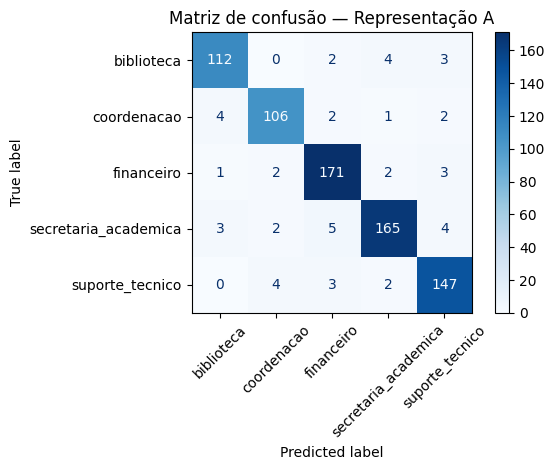

In [7]:
classes = list(modelo_A.classes_)

cm_A = confusion_matrix(y_validacao, pred_A, labels=classes)

disp_A = ConfusionMatrixDisplay(confusion_matrix=cm_A, display_labels=classes)
disp_A.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusão — Representação A")
plt.tight_layout()
plt.show()


# Parte B — Representação B

## 8. TF-IDF com unigramas + bigramas

Agora alteramos apenas `ngram_range`.

**Pergunta:** o comportamento do sistema muda quando a representação inclui combinações locais de duas palavras?


In [8]:
vetorizador_B = TfidfVectorizer(ngram_range=(1, 2))

X_treino_B = vetorizador_B.fit_transform(treino[COL_TEXTO])
X_validacao_B = vetorizador_B.transform(validacao[COL_TEXTO])

print("Representação B — treino:", X_treino_B.shape)
print("Representação B — validação:", X_validacao_B.shape)
print("Número de atributos B:", X_treino_B.shape[1])


Representação B — treino: (3470, 2278)
Representação B — validação: (750, 2278)
Número de atributos B: 2278


## 9. Treinar e avaliar o Modelo B

O classificador continua exatamente igual ao da Representação A.


In [9]:
modelo_B = LogisticRegression(max_iter=1000, random_state=42)
modelo_B.fit(X_treino_B, y_treino)

pred_B = modelo_B.predict(X_validacao_B)

acc_B = accuracy_score(y_validacao, pred_B)
f1_B = f1_score(y_validacao, pred_B, average="macro", zero_division=0)

print(f"Acurácia B: {acc_B:.3f}")
print(f"F1-macro B: {f1_B:.3f}")


Acurácia B: 0.960
F1-macro B: 0.959


## 10. Matriz de confusão — Modelo B

Compare com a matriz A:

- algum erro desapareceu?
- algum erro surgiu?
- alguma classe passou a ser confundida de outra forma?


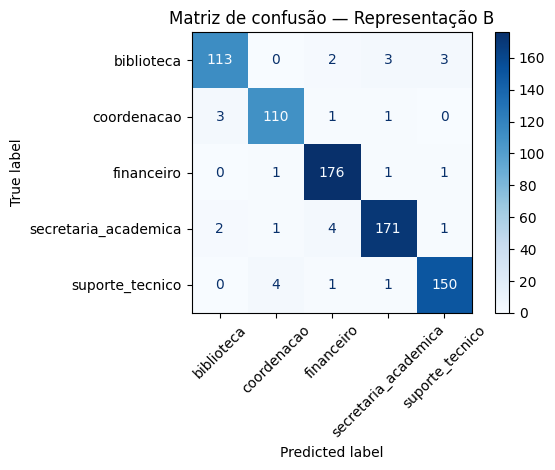

In [10]:
cm_B = confusion_matrix(y_validacao, pred_B, labels=classes)

disp_B = ConfusionMatrixDisplay(confusion_matrix=cm_B, display_labels=classes)
disp_B.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusão — Representação B")
plt.tight_layout()
plt.show()


# Parte C — Comparar as evidências

## 11. Tabela comparativa

Acurácia e F1-macro são métricas de desempenho.  
O número de atributos descreve a estrutura da representação — **não é uma métrica de desempenho**.


In [11]:
comparacao = pd.DataFrame({
    "Representação": ["A — unigramas", "B — unigramas + bigramas"],
    "Acurácia": [acc_A, acc_B],
    "F1-macro": [f1_A, f1_B],
    "Nº atributos": [X_treino_A.shape[1], X_treino_B.shape[1]],
})

display(comparacao.round(3))


,Representação,Acurácia,F1-macro,Nº atributos
0,A — unigramas,0.935,0.934,288
1,B — unigramas + bigramas,0.960,0.959,2278


## 12. Comparar previsões exemplo a exemplo

Uma métrica global pode permanecer igual mesmo quando os erros mudam.

Vamos localizar os textos nos quais A e B produziram decisões diferentes.


In [12]:
analise = validacao[[COL_TEXTO, COL_ALVO]].copy()
analise["pred_A"] = pred_A
analise["pred_B"] = pred_B
analise["A_correto"] = analise["pred_A"] == analise[COL_ALVO]
analise["B_correto"] = analise["pred_B"] == analise[COL_ALVO]
analise["A_diferente_B"] = analise["pred_A"] != analise["pred_B"]

divergencias = analise[analise["A_diferente_B"]].copy()

print("Exemplos em que A e B divergem:", len(divergencias))
display(divergencias.head(20))


Exemplos em que A e B divergem: 21


,texto,setor_destino,pred_A,pred_B,A_correto,B_correto,A_diferente_B
116,"Estou com uma dúvida, quero confirmar o status...",secretaria_academica,biblioteca,secretaria_academica,False,True,True
490,"estou com uma dúvida, o link de recuperação de...",suporte_tecnico,financeiro,suporte_tecnico,False,True,True
673,"Gente, preciso avaliar uma situação excepciona...",secretaria_academica,coordenacao,secretaria_academica,False,True,True
934,"Então, venho informar, quero entender uma cobr...",financeiro,coordenacao,financeiro,False,True,True
1136,Preciso de informações sobre vencimento e juro...,financeiro,secretaria_academica,financeiro,False,True,True
1851,Registro a seguinte situação: preciso conversa...,suporte_tecnico,coordenacao,suporte_tecnico,False,True,True
1921,"O SISTEMA FECHA ANTES DE CONCLUIR A OPERAÇÃO, ...",suporte_tecnico,secretaria_academica,suporte_tecnico,False,True,True
2039,Preciso conversar sobre a organização da minha...,coordenacao,suporte_tecnico,coordenacao,False,True,True
2349,O link de recuperação de senha não chega. Além...,financeiro,suporte_tecnico,financeiro,False,True,True
2374,Quero confirmar o status da rematrícula; ao me...,biblioteca,secretaria_academica,biblioteca,False,True,True


## 13. Separar padrões de mudança

Vamos distinguir quatro situações:

1. A errou e B corrigiu
2. A acertou e B passou a errar
3. ambas erraram
4. ambas acertaram

O objetivo é investigar comportamento, não declarar automaticamente uma representação como melhor.


In [13]:
A_errou_B_corrigiu = analise[(analise["A_correto"] == False) & (analise["B_correto"] == True)]
A_acertou_B_errou = analise[(analise["A_correto"] == True) & (analise["B_correto"] == False)]
ambas_erraram = analise[(analise["A_correto"] == False) & (analise["B_correto"] == False)]
ambas_acertaram = analise[(analise["A_correto"] == True) & (analise["B_correto"] == True)]

resumo_mudancas = pd.DataFrame({
    "Situação": [
        "A errou / B corrigiu",
        "A acertou / B errou",
        "Ambas erraram",
        "Ambas acertaram",
    ],
    "Quantidade": [
        len(A_errou_B_corrigiu),
        len(A_acertou_B_errou),
        len(ambas_erraram),
        len(ambas_acertaram),
    ],
})

display(resumo_mudancas)


,Situação,Quantidade
0,A errou / B corrigiu,20
1,A acertou / B errou,1
2,Ambas erraram,29
3,Ambas acertaram,700


# Parte D — Análise de erros

## 14. Inspecionar casos concretos

Primeiro, verifique se a validação produziu erros ou divergências entre A e B.

### Caminho A — existem erros ou divergências

Selecione 2 ou 3 casos que mereçam investigação.

Procure sinais como:

- ambiguidade entre classes
- texto muito curto
- informação insuficiente
- vocabulário compartilhado
- negação
- formulação incomum
- possível problema de rótulo

### Caminho B — não existem erros nem divergências

Isso **também é um resultado experimental**.

Não invente erros e não conclua que a Representação B é superior. Registre:

> Nesta validação, as duas representações produziram o mesmo comportamento observado e não forneceram erros suficientes para investigar a hipótese.

Depois responda:

> **Que tipo de exemplo novo seria necessário para colocar a hipótese à prova?**


In [14]:
erros_para_inspecao = analise[
    (analise["A_correto"] == False) | (analise["B_correto"] == False)
].copy()

print("Casos com pelo menos um erro:", len(erros_para_inspecao))
print("Divergências entre A e B:", len(divergencias))

if len(erros_para_inspecao) > 0:
    print("\nCaminho A — há erros para investigar.")
    candidatos_inspecao = erros_para_inspecao.copy()
    display(candidatos_inspecao.head(20))
else:
    print("\nCaminho B — não houve erros nesta validação.")
    print("Não invente casos. Registre a ausência de erros como evidência.")
    print("Pergunta: que exemplos novos seriam necessários para testar melhor a hipótese?")
    candidatos_inspecao = erros_para_inspecao.copy()


Casos com pelo menos um erro: 50
Divergências entre A e B: 21

Caminho A — há erros para investigar.


,texto,setor_destino,pred_A,pred_B,A_correto,B_correto,A_diferente_B
116,"Estou com uma dúvida, quero confirmar o status...",secretaria_academica,biblioteca,secretaria_academica,False,True,True
269,"bom dia, preciso da segunda via do boleto. alé...",biblioteca,financeiro,financeiro,False,False,False
395,"Só queria entender, não consigo entrar no port...",suporte_tecnico,coordenacao,coordenacao,False,False,False
480,Quero conversar sobre pré-requisitos e sequênc...,coordenacao,financeiro,financeiro,False,False,False
490,"estou com uma dúvida, o link de recuperação de...",suporte_tecnico,financeiro,suporte_tecnico,False,True,True
553,"Olá, o sistema fecha antes de concluir a opera...",biblioteca,suporte_tecnico,suporte_tecnico,False,False,False
565,não consigo abrir o ambiente virtual; ao mesmo...,biblioteca,suporte_tecnico,suporte_tecnico,False,False,False
673,"Gente, preciso avaliar uma situação excepciona...",secretaria_academica,coordenacao,secretaria_academica,False,True,True
691,"boa tarde, aparece uma mensagem de erro toda v...",financeiro,suporte_tecnico,suporte_tecnico,False,False,False
818,"Olá, meu nome saiu incorreto em um documento a...",secretaria_academica,biblioteca,biblioteca,False,False,False


## 15. Registrar os casos investigados — ou a ausência deles

### Se houver erros

Selecione até 3 casos a partir da tabela anterior.  
Os dados já conhecidos pelo notebook serão reaproveitados; você deverá acrescentar apenas a **classificação do caso** e a **observação interpretativa**.

### Se não houver erros

Não preencha casos fictícios. Registre explicitamente que a validação não ofereceu erros para análise e formule qual evidência nova seria necessária.

Evite conclusões fortes como “bigramas resolveram o problema”.  
Prefira formulações condicionadas à validação observada.


In [15]:
if len(candidatos_inspecao) > 0:
    # Casos escolhidos: um de cada situação relevante (A errou/B corrigiu; ambas erraram; A acertou/B errou).
    indices_escolhidos = [116, 269, 2800]

    casos_analisados = candidatos_inspecao.loc[
        indices_escolhidos,
        [COL_TEXTO, COL_ALVO, "pred_A", "pred_B"]
    ].copy()

    casos_analisados["tipo_de_caso"] = [
        "A errou / B corrigiu",
        "ambas erraram",
        "A acertou / B errou",
    ]
    casos_analisados["observacao"] = [
        "Texto com dois pedidos (rematrícula + livro). O rótulo é secretaria_academica. A previsou biblioteca; B acertou, possivelmente pelo bigrama 'status da rematrícula'.",
        "Texto com dois pedidos (boleto + base de periódicos). O rótulo é biblioteca, mas ambos previram financeiro. A ordem dos assuntos não parece determinar o rótulo, e os bigramas não resolveram a ambiguidade.",
        "Texto com dois pedidos (sistema fecha + orientação sobre turma). Só A acertou; B passou a prever coordenacao. Único caso em que B piorou.",
    ]

    display(casos_analisados)
else:
    casos_analisados = pd.DataFrame(
        columns=[COL_TEXTO, COL_ALVO, "pred_A", "pred_B", "tipo_de_caso", "observacao"]
    )

    registro_sem_erros = {
        "resultado_observado": (
            "Nesta validação, não houve erros para analisar nas representações A e B."
        ),
        "evidencia_nova_necessaria": "PREENCHER",
    }

    display(registro_sem_erros)


,texto,setor_destino,pred_A,pred_B,tipo_de_caso,observacao
116,"Estou com uma dúvida, quero confirmar o status...",secretaria_academica,biblioteca,secretaria_academica,A errou / B corrigiu,Texto com dois pedidos (rematrícula + livro). ...
269,"bom dia, preciso da segunda via do boleto. alé...",biblioteca,financeiro,financeiro,ambas erraram,Texto com dois pedidos (boleto + base de perió...
2800,"O sistema fecha antes de concluir a operação, ...",suporte_tecnico,suporte_tecnico,coordenacao,A acertou / B errou,Texto com dois pedidos (sistema fecha + orient...


# Parte E — Da observação à hipótese

## 16. Formular uma hipótese experimental

Uma hipótese é uma expectativa testável.

Exemplo de forma adequada:

> “A inclusão de bigramas pode ajudar em textos nos quais combinações locais de palavras carregam informação relevante.”

Evite:

> “Bigramas são melhores.”


In [16]:
registro_investigacao = {
    "observacao_principal": (
        "Nesta validação, B (1,2) teve 0.960 de acurácia e 0.959 de F1-macro, contra 0.935 e 0.934 de A (1,1). "
        "Ambas as representações erraram 29 textos (50 com pelo menos um erro). Na matriz de B, 14 dos 30 erros "
        "ficaram em 3 dos 10 pares de setores: biblioteca×secretaria_academica (5), financeiro×secretaria_academica (5) "
        "e coordenacao×suporte_tecnico (4). Nos casos inspecionados, os textos difíceis trazem dois pedidos de setores diferentes."
    ),
    "hipotese": (
        "Os casos mais difíceis podem se concentrar em alguns pares de setores, sobretudo os que envolvem "
        "secretaria_academica (com biblioteca e com financeiro) e coordenacao×suporte_tecnico, e não se distribuir "
        "por igual entre todos os pares."
    ),
    "questao_experimental_preliminar": (
        "Trilha A: quais pares de setores concentram os casos mais difíceis do P03 (erros das duas representações) "
        "e o que esses pares têm em comum?"
    ),
    "evidencia_futura_necessaria": (
        "Mais exemplos, na extensão do corpus, com pedidos que envolvam os pares de setores mais confundidos, "
        "incluindo textos com um único pedido e textos com dois pedidos, para verificar se a concentração se mantém. "
        "Também convém conferir se o rótulo dos textos com dois pedidos é consistente."
    ),
}

display(registro_investigacao)

# Registre o tipo principal de evidência que motivou a investigação.
tipo_evidencia = "ambas erraram"
print("Tipo de evidência:", tipo_evidencia)


{'observacao_principal': 'Nesta validação, B (1,2) teve 0.960 de acurácia e 0.959 de F1-macro, contra 0.935 e 0.934 de A (1,1). Ambas as representações erraram 29 textos (50 com pelo menos um erro). Na matriz de B, 14 dos 30 erros ficaram em 3 dos 10 pares de setores: biblioteca×secretaria_academica (5), financeiro×secretaria_academica (5) e coordenacao×suporte_tecnico (4). Nos casos inspecionados, os textos difíceis trazem dois pedidos de setores diferentes.',
 'hipotese': 'Os casos mais difíceis podem se concentrar em alguns pares de setores, sobretudo os que envolvem secretaria_academica (com biblioteca e com financeiro) e coordenacao×suporte_tecnico, e não se distribuir por igual entre todos os pares.',
 'questao_experimental_preliminar': 'Trilha A: quais pares de setores concentram os casos mais difíceis do P03 (erros das duas representações) e o que esses pares têm em comum?',
 'evidencia_futura_necessaria': 'Mais exemplos, na extensão do corpus, com pedidos que envolvam os pares

Tipo de evidência: ambas erraram


## 17. Síntese da comparação

Complete a síntese sem transformar diferença em superioridade automática.

Use formulações como:

- “Nesta validação, observamos que...”
- “A alteração de `ngram_range` produziu...”
- “Os principais erros concentraram-se em...”
- “Esse resultado ainda não permite concluir que...”


## Tipo de evidência que motivou a investigação
Antes do registro final, identifique a evidência principal que originou a hipótese:
- divergência A×B
- A errou / B corrigiu
- A acertou / B errou
- ambas erraram
- ausência de diferença relevante
- outro caso difícil justificado


In [17]:
registro_final_M16 = {
    "corpus": ARQUIVO,
    "variavel_experimental": "ngram_range",
    "A": {
        "configuracao": "(1, 1)",
        "acuracia": round(acc_A, 3),
        "f1_macro": round(f1_A, 3),
        "n_atributos": X_treino_A.shape[1],
    },
    "B": {
        "configuracao": "(1, 2)",
        "acuracia": round(acc_B, 3),
        "f1_macro": round(f1_B, 3),
        "n_atributos": X_treino_B.shape[1],
    },
    "divergencias_A_B": len(divergencias),
    "erros_para_inspecao": len(erros_para_inspecao),
    "interpretacao": "Nesta validação, a alteração de ngram_range de (1,1) para (1,2) veio acompanhada de aumento de 0.025 na acurácia (750 exemplos) e de 20 correções contra 1 piora. Os erros restantes de ambas as representações concentram-se em textos com dois pedidos de setores diferentes.",
    "limitacao": "Este resultado ainda não permite concluir que bigramas são melhores em geral: vem de uma única validação de 750 exemplos, uma única semente e um único classificador, sem intervalo de confiança. B também tem cerca de 8 vezes mais atributos que A (2278 contra 288), o que não é métrica de desempenho. O corpus tem textos com estrutura repetitiva, e o rótulo dos textos com dois pedidos pode ser ambíguo.",
    "hipotese": registro_investigacao["hipotese"],
    "questao_experimental_preliminar":
        registro_investigacao["questao_experimental_preliminar"],
    "evidencia_futura_necessaria":
        registro_investigacao["evidencia_futura_necessaria"],
}

display(registro_final_M16)


{'corpus': 'P03_solicitacoes_atendimento_v2.csv',
 'variavel_experimental': 'ngram_range',
 'A': {'configuracao': '(1, 1)',
  'acuracia': 0.935,
  'f1_macro': 0.934,
  'n_atributos': 288},
 'B': {'configuracao': '(1, 2)',
  'acuracia': 0.96,
  'f1_macro': 0.959,
  'n_atributos': 2278},
 'divergencias_A_B': 21,
 'erros_para_inspecao': 50,
 'interpretacao': 'Nesta validação, a alteração de ngram_range de (1,1) para (1,2) veio acompanhada de aumento de 0.025 na acurácia (750 exemplos) e de 20 correções contra 1 piora. Os erros restantes de ambas as representações concentram-se em textos com dois pedidos de setores diferentes.',
 'limitacao': 'Este resultado ainda não permite concluir que bigramas são melhores em geral: vem de uma única validação de 750 exemplos, uma única semente e um único classificador, sem intervalo de confiança. B também tem cerca de 8 vezes mais atributos que A (2278 contra 288), o que não é métrica de desempenho. O corpus tem textos com estrutura repetitiva, e o rót

## 18. Verificação final de governança

Antes de encerrar, confirme:

- [ ] usei o mesmo corpus e as mesmas partições
- [ ] mantive o classificador fixo
- [ ] alterei apenas `ngram_range`
- [ ] comparei acurácia, F1-macro e matriz
- [ ] examinei exemplos concretos ou registrei justificadamente a ausência de erros para análise
- [ ] formulei uma hipótese
- [ ] formulei uma questão experimental preliminar
- [ ] não usei o teste para aprender, comparar ou decidir

> **Saída da Aula 6:** comparação controlada + análise de erros + hipótese + questão experimental preliminar.  
> **Ponte:** preparar evidência nova na extensão do corpus, mantendo o teste preservado.


# Parte E2 — Extensão do corpus (M4, Trilha A)

**Questão experimental (Trilha A):** quais pares de setores concentram os casos mais difíceis do P03 (erros das duas representações) e o que esses pares têm em comum?

Configuração congelada no M4: **B — TF-IDF unigramas + bigramas (1,2)**, sem novo `fit`. A extensão (`P03_extensao_TrilhaA.csv`) é um arquivo separado do corpus-base, com 120 exemplos gerados com apoio de IA (Claude); a revisão dos rótulos pelo grupo é registrada na coluna `revisado_pelo_grupo` do CSV. Esta parte **não usa o teste**.


In [18]:
import numpy as np

ARQUIVO_EXT = "P03_extensao_TrilhaA.csv"
ext = pd.read_csv(ARQUIVO_EXT, sep=";", encoding="utf-8-sig")

assert len(ext) >= 80 and ext["id"].is_unique
assert ext[COL_TEXTO].isna().sum() == 0 and ext[COL_ALVO].isna().sum() == 0
assert set(ext[COL_ALVO]).issubset(set(treino[COL_ALVO]))
textos_base = set(pd.concat([treino, validacao])[COL_TEXTO])
assert not set(ext[COL_TEXTO]).intersection(textos_base), "A extensão não deve repetir textos do treino nem da validação."

# Apenas transform e predict: nenhum novo fit.
X_ext = vetorizador_B.transform(ext[COL_TEXTO])
ext["pred_B"] = modelo_B.predict(X_ext)
ext["correto"] = ext["pred_B"] == ext[COL_ALVO]

ext["tipo"] = np.where(
    ext["n_pedidos"] == 1, "um pedido",
    np.where(ext["marcador_prioridade"] == "sim", "dois pedidos, com marcador", "dois pedidos, sem marcador (ambíguo)")
)

acc_ext = accuracy_score(ext[COL_ALVO], ext["pred_B"])
f1_ext = f1_score(ext[COL_ALVO], ext["pred_B"], average="macro", zero_division=0)
print(f"Extensão ({len(ext)} exemplos) — acurácia: {acc_ext:.3f} | F1-macro: {f1_ext:.3f} | erros: {(~ext['correto']).sum()}")


Extensão (120 exemplos) — acurácia: 0.683 | F1-macro: 0.677 | erros: 38


In [19]:
resumo_tipo = ext.groupby("tipo")["correto"].agg(exemplos="size", acertos="sum", acuracia="mean").round(3)
resumo_par = ext.groupby("par_alvo")["correto"].agg(exemplos="size", acertos="sum", acuracia="mean").round(3)

display(resumo_tipo)
display(resumo_par)


,exemplos,acertos,acuracia
tipo,,,
"dois pedidos, com marcador",42,21,0.500
"dois pedidos, sem marcador (ambíguo)",18,8,0.444
um pedido,60,53,0.883


,exemplos,acertos,acuracia
par_alvo,,,
biblioteca×secretaria_academica,40,27,0.675
coordenacao×suporte_tecnico,40,29,0.725
financeiro×secretaria_academica,40,26,0.650


In [20]:
def pares_confundidos(real, previsto):
    """Conta os erros por par NÃO ordenado de setores (real × previsto)."""
    err = real != previsto
    pares = [" × ".join(sorted([r, p])) for r, p in zip(real[err], previsto[err])]
    return pd.Series(pares, dtype="object").value_counts()

pares_validacao_B = pares_confundidos(analise[COL_ALVO], analise["pred_B"])
pares_extensao_B = pares_confundidos(ext[COL_ALVO], ext["pred_B"])

comparacao_pares = (
    pd.concat([pares_validacao_B.rename("validação (750)"), pares_extensao_B.rename("extensão (120)")], axis=1)
      .fillna(0).astype(int)
)
comparacao_pares["total"] = comparacao_pares.sum(axis=1)
comparacao_pares = comparacao_pares.sort_values("total", ascending=False)

display(comparacao_pares)
print("Erros na validação:", int(pares_validacao_B.sum()), "| erros na extensão:", int(pares_extensao_B.sum()))


,validação (750),extensão (120),total
financeiro × secretaria_academica,5,12,17
biblioteca × secretaria_academica,5,11,16
coordenacao × suporte_tecnico,4,10,14
biblioteca × suporte_tecnico,3,1,4
biblioteca × financeiro,2,2,4
coordenacao × secretaria_academica,2,2,4
biblioteca × coordenacao,3,0,3
coordenacao × financeiro,2,0,2
financeiro × suporte_tecnico,2,0,2
secretaria_academica × suporte_tecnico,2,0,2


Erros na validação: 30 | erros na extensão: 38


# Parte F — Aula 8: aplicação final na partição de teste

## 19. Gate antes do teste final

**Execute esta parte somente depois de encerrar as decisões de desenvolvimento e registrar no M4:**

- questão experimental
- corpus/extensão usada na investigação
- preparação
- representação final
- classificador e configuração
- métricas que serão lidas

> **Regra:** o resultado do teste serve para verificar e interpretar o pipeline final. Ele não deve ser usado para escolher uma nova configuração.

As células anteriores de validação **não devem ser substituídas nem apagadas**.


In [21]:
# Escolha SOMENTE a configuração já definida antes de consultar o teste.
# Não altere esta escolha depois de observar o resultado do teste.
CONFIG_FINAL = "B"  # use "A" ou "B" conforme a decisão registrada no M4

assert CONFIG_FINAL in {"A", "B"}, 'Use somente "A" ou "B".'

if CONFIG_FINAL == "A":
    vetorizador_final = vetorizador_A
    modelo_final = modelo_A
    nome_config_final = "A — TF-IDF unigramas (1,1)"
else:
    vetorizador_final = vetorizador_B
    modelo_final = modelo_B
    nome_config_final = "B — TF-IDF unigramas + bigramas (1,2)"

print("Configuração final congelada:", nome_config_final)
print("Próximo passo: aplicar esta configuração à partição de teste sem novo fit.")


Configuração final congelada: B — TF-IDF unigramas + bigramas (1,2)
Próximo passo: aplicar esta configuração à partição de teste sem novo fit.


## 20. Aplicar o pipeline final ao conjunto de teste

Aqui o teste entra pela primeira vez na representação e na previsão.

Observe a diferença:

- usamos `transform`, porque o TF-IDF já foi ajustado no treino
- usamos `predict`, porque o classificador já foi ajustado no treino
- **não usamos `fit` nem `fit_transform` no teste**


In [22]:
y_teste = teste[COL_ALVO]

assert teste[COL_TEXTO].isna().sum() == 0
assert teste[COL_ALVO].isna().sum() == 0
assert set(teste[COL_ALVO]).issubset(set(treino[COL_ALVO]))

X_teste_final = vetorizador_final.transform(teste[COL_TEXTO])
pred_teste_final = modelo_final.predict(X_teste_final)

print("Teste:", X_teste_final.shape)
print("Previsões produzidas:", len(pred_teste_final))
print("Nenhum novo fit foi realizado.")


Teste: (750, 2278)
Previsões produzidas: 750
Nenhum novo fit foi realizado.


## 21. Registrar as evidências quantitativas finais

As métricas abaixo descrevem o comportamento do **pipeline já definido** no conjunto de teste.

Na Aula 8, use:

- acurácia
- F1-macro
- precisão e recall por classe, quando forem úteis para responder à questão experimental

Não escolha uma nova configuração a partir destes valores.


In [23]:
from sklearn.metrics import classification_report

acc_teste = accuracy_score(y_teste, pred_teste_final)
f1_teste = f1_score(y_teste, pred_teste_final, average="macro", zero_division=0)

print(f"Configuração final: {nome_config_final}")
print(f"Acurácia no teste: {acc_teste:.3f}")
print(f"F1-macro no teste: {f1_teste:.3f}")

relatorio_teste = classification_report(
    y_teste,
    pred_teste_final,
    labels=classes,
    output_dict=True,
    zero_division=0,
)

tabela_metricas_teste = (
    pd.DataFrame(relatorio_teste)
      .T
      .loc[classes, ["precision", "recall", "f1-score", "support"]]
)

display(tabela_metricas_teste.round(3))


Configuração final: B — TF-IDF unigramas + bigramas (1,2)
Acurácia no teste: 0.951
F1-macro no teste: 0.949


,precision,recall,f1-score,support
biblioteca,0.956,0.885,0.919,122.0
coordenacao,0.957,0.948,0.952,116.0
financeiro,0.927,0.994,0.959,178.0
secretaria_academica,0.971,0.949,0.960,178.0
suporte_tecnico,0.949,0.955,0.952,156.0


## 22. Matriz de confusão — teste final

Use a matriz para localizar onde os erros se concentram.

- linhas: classe real
- colunas: classe prevista
- diagonal: acertos
- fora da diagonal: erros

A matriz ajuda a interpretar o resultado; ela não abre uma nova rodada de ajuste.


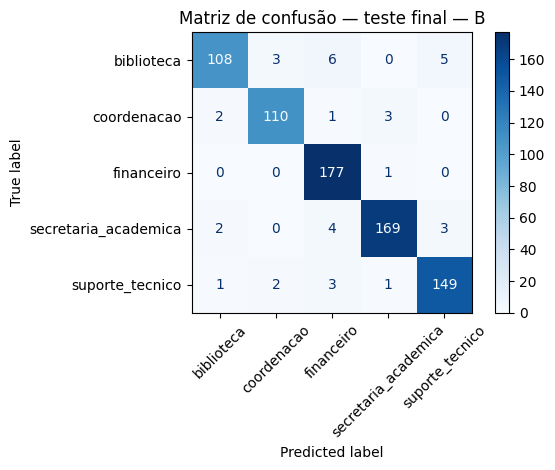

In [24]:
cm_teste = confusion_matrix(y_teste, pred_teste_final, labels=classes)

disp_teste = ConfusionMatrixDisplay(
    confusion_matrix=cm_teste,
    display_labels=classes,
)

disp_teste.plot(cmap="Blues", xticks_rotation=45)
plt.title(f"Matriz de confusão — teste final — {CONFIG_FINAL}")
plt.tight_layout()
plt.show()


## 23. Selecionar um caso difícil do teste para interpretação final

Agora é legítimo inspecionar erros do teste, porque as decisões já foram encerradas.

Use o caso para **interpretar e limitar a conclusão**, não para voltar e alterar o pipeline.


In [25]:
analise_teste = teste[[COL_TEXTO, COL_ALVO]].copy()
analise_teste["pred_final"] = pred_teste_final
analise_teste["correto"] = analise_teste["pred_final"] == analise_teste[COL_ALVO]

erros_teste = analise_teste[analise_teste["correto"] == False].copy()

print("Erros no teste:", len(erros_teste))

if len(erros_teste) > 0:
    display(erros_teste.head(20))
    print("Selecione um caso informativo para registrar no M4.")
else:
    print("Não houve erro observado no teste para esta configuração.")
    print("Registre a ausência de erros como resultado, sem extrapolar para dados futuros.")


Erros no teste: 37


,texto,setor_destino,pred_final,correto
176,"Olá, minha senha não funciona. Além disso, pre...",biblioteca,suporte_tecnico,False
251,Quero negociar uma pendência financeira; ao me...,biblioteca,financeiro,False
340,"preciso consultar uma pendência de empréstimo,...",biblioteca,suporte_tecnico,False
471,preciso da segunda via do boleto; ao mesmo tem...,secretaria_academica,financeiro,False
572,"Pessoal, a devolução de um livro ainda não foi...",biblioteca,coordenacao,False
660,meu nome saiu incorreto em um documento acadêm...,secretaria_academica,suporte_tecnico,False
672,"quero entender o procedimento de trancamento, ...",secretaria_academica,financeiro,False
850,Meu nome saiu incorreto em um documento acadêm...,coordenacao,secretaria_academica,False
888,Quero saber se um título está disponível. Além...,coordenacao,biblioteca,False
893,"Então, minha matricula não aparece corretament...",secretaria_academica,suporte_tecnico,False


Selecione um caso informativo para registrar no M4.


In [26]:
# Higiene de dados: a extensão não deve repetir textos do teste.
assert not set(ext[COL_TEXTO]).intersection(set(teste[COL_TEXTO])), "A extensão repete texto do teste."

pares_teste_B = pares_confundidos(analise_teste[COL_ALVO], analise_teste["pred_final"])
display(pares_teste_B.to_frame("erros no teste"))
print("Erros no teste:", int(pares_teste_B.sum()))


,erros no teste
biblioteca × suporte_tecnico,6
biblioteca × financeiro,6
financeiro × secretaria_academica,5
biblioteca × coordenacao,5
secretaria_academica × suporte_tecnico,4
coordenacao × secretaria_academica,3
financeiro × suporte_tecnico,3
biblioteca × secretaria_academica,2
coordenacao × suporte_tecnico,2
coordenacao × financeiro,1


Erros no teste: 37


## 24. Registro final para o M4

Complete a interpretação sem transformar o resultado em afirmação universal.

Uma redação defensável deve separar:

1. resultado observado
2. interpretação
3. conclusão em relação à questão experimental
4. limitação


In [27]:
registro_teste_final = {
    "configuracao_final": nome_config_final,
    "acuracia_teste": round(acc_teste, 3),
    "f1_macro_teste": round(f1_teste, 3),
    "numero_erros_teste": len(erros_teste),
    "resultado_observado": (
        "No teste, B teve acurácia 0.951, F1-macro 0.949 e 37 erros em 750 textos (validação: 0.960 e 30 erros). "
        "O menor recall foi o de biblioteca (0.885). Todos os 37 erros estão em textos com marcadores de dois pedidos; "
        "os textos sem esses marcadores foram todos acertados. Os 3 pares mais confundidos na validação somaram 9 dos 37 erros do teste "
        "(financeiro×secretaria_academica 5, biblioteca×secretaria_academica 2, coordenacao×suporte_tecnico 2). "
        "Na extensão (120 exemplos), B teve acurácia 0.683: 0.883 com um pedido, 0.500 com dois pedidos e marcador, 0.444 com dois pedidos sem marcador."
    ),
    "interpretacao": (
        "Nesta validação e neste teste, a dificuldade do pipeline B está nos textos com dois pedidos de setores diferentes, e não em pares específicos: "
        "a concentração observada na validação (14 de 30 erros em 3 pares) não se repetiu no teste (9 de 37, abaixo dos 30% esperados se todos os pares fossem iguais). "
        "Os erros do teste se espalharam por vários pares, e biblioteca aparece em 19 dos 37 (14 casos em que biblioteca era o rótulo real). "
        "Na extensão, a queda de acurácia ocorreu mesmo quando havia marcador de prioridade, o que sugere que TF-IDF com bigramas não usa esse marcador para decidir qual pedido é o principal."
    ),
    "questao_experimental_respondida": (
        "Parcialmente. Os dados não sustentam que pares específicos concentrem os casos mais difíceis; sustentam que os casos difíceis são os textos com dois pedidos. "
        "A extensão foi construída apenas com os 3 pares da validação, então não permite testar a concentração por par."
    ),
    "conclusao": (
        "enfraquecida — a hipótese de concentração nos pares da validação não se repetiu no teste; o que se repetiu nos dois conjuntos foi a dificuldade em textos com dois pedidos."
    ),
    "limitacao_principal": (
        "A extensão é sintética, gerada com apoio de IA e limitada a 3 pares; seu estilo difere do corpus-base (acurácia 0.683 contra 0.951 no teste), então parte da queda pode vir da mudança de escrita. "
        "Com 30 e 37 erros, as contagens por par são pequenas. Os 3 pares foram escolhidos depois de ver os erros da validação, o que infla a concentração observada (14 de 30). Um único classificador e uma única partição, sem intervalo de confiança."
    ),
}

display(registro_teste_final)


{'configuracao_final': 'B — TF-IDF unigramas + bigramas (1,2)',
 'acuracia_teste': 0.951,
 'f1_macro_teste': 0.949,
 'numero_erros_teste': 37,
 'resultado_observado': 'No teste, B teve acurácia 0.951, F1-macro 0.949 e 37 erros em 750 textos (validação: 0.960 e 30 erros). O menor recall foi o de biblioteca (0.885). Todos os 37 erros estão em textos com marcadores de dois pedidos; os textos sem esses marcadores foram todos acertados. Os 3 pares mais confundidos na validação somaram 9 dos 37 erros do teste (financeiro×secretaria_academica 5, biblioteca×secretaria_academica 2, coordenacao×suporte_tecnico 2). Na extensão (120 exemplos), B teve acurácia 0.683: 0.883 com um pedido, 0.500 com dois pedidos e marcador, 0.444 com dois pedidos sem marcador.',
 'interpretacao': 'Nesta validação e neste teste, a dificuldade do pipeline B está nos textos com dois pedidos de setores diferentes, e não em pares específicos: a concentração observada na validação (14 de 30 erros em 3 pares) não se repetiu

## 25. Verificação final — depois do teste

Antes de encerrar:

- [ ] a configuração final já estava registrada antes de executar a Parte F
- [ ] não fiz `fit` nem `fit_transform` no teste
- [ ] não troquei A/B depois de observar o resultado do teste
- [ ] registrei acurácia e F1-macro do teste
- [ ] examinei precisão/recall por classe apenas quando pertinentes à questão
- [ ] li a matriz de confusão e selecionei um caso difícil quando existente
- [ ] usei o teste para interpretar, não para otimizar
- [ ] registrei conclusão e limitação no M4

> **Saída da Aula 8:** resultado final do pipeline congelado + interpretação + caso difícil + conclusão + limitação.
